# META + SHOP — Estrategia V2 combinada

Backtest desde el **1 de enero de 2025** con un capital único de 10.000 USD y como máximo una posición abierta.

- Compara `META sola`, `SHOP sola` y `META + SHOP combinadas`.
- Las señales se calculan al cierre y se ejecutan en la apertura siguiente.
- Mientras existe una posición no se aceptan nuevas entradas. Al cerrarla, la cartera vuelve a vigilar los valores disponibles.
- Si ambos valores presentan una señal simultánea, se elige la más extrema normalizada por ATR, sin utilizar información futura.
- Los shorts RSI conservan la salida `RSI < 50`; los shorts por ruptura usan la salida V2.

No incluye comisiones, deslizamiento, dividendos, intereses del efectivo ni costes de préstamo de acciones para posiciones cortas.


In [1]:
# Si fuera necesario: %pip install -q yfinance matplotlib pandas numpy
import warnings
import tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython import get_ipython
from IPython.display import display

warnings.filterwarnings('ignore')
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_meta_shop_combi_cache'))
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

TICKERS = ['META', 'SHOP']
FECHA_INICIO = pd.Timestamp('2025-01-01')
CAPITAL_INICIAL = 10_000
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20

descarga = yf.download(
    TICKERS, start=FECHA_INICIO - pd.Timedelta(days=90), interval='1d',
    auto_adjust=False, progress=False, group_by='column', threads=False
)
if descarga.empty:
    raise RuntimeError('No se pudieron descargar datos de META y SHOP.')

datos_raw = {}
for ticker in TICKERS:
    d = pd.DataFrame({campo: descarga[campo][ticker]
                      for campo in ['Open', 'High', 'Low', 'Close', 'Volume']}).dropna()
    if d.empty:
        raise RuntimeError(f'No se pudieron descargar datos de {ticker}.')
    datos_raw[ticker] = d

ultima_fecha_comun = min(d.index.max() for d in datos_raw.values())
print(f'Periodo evaluado: {FECHA_INICIO.date()} → {ultima_fecha_comun.date()}')


Periodo evaluado: 2025-01-01 → 2026-08-21


In [2]:
def preparar_senales(df):
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desv = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desv
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()
    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([d['High'] - d['Low'],
                    (d['High'] - cierre_previo).abs(),
                    (d['Low'] - cierre_previo).abs()], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = ((d['Close'] < d['MINIMO_20_PREV']) &
                          (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN))
    return d

datos = {ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
         for ticker, d in datos_raw.items()}


In [3]:
def candidato_entrada(ticker, senal):
    if bool(senal['LONG_ENTRY']):
        # Distancia bajo la banda, escalada por ATR.
        fuerza = (float(senal['BB_LOWER']) - float(senal['Close'])) / float(senal['ATR14'])
        return {'Ticker': ticker, 'Tipo': 'LONG', 'Sistema entrada': 'RSI + BOLLINGER',
                'Fuerza': fuerza}
    if bool(senal['SHORT_RUPTURA']):
        fuerza = (float(senal['MINIMO_20_PREV']) - float(senal['Close'])) / float(senal['ATR14'])
        return {'Ticker': ticker, 'Tipo': 'SHORT', 'Sistema entrada': 'RUPTURA',
                'Fuerza': fuerza}
    if bool(senal['SHORT_RSI']):
        fuerza = (float(senal['RSI']) - 70) / 10
        return {'Ticker': ticker, 'Tipo': 'SHORT', 'Sistema entrada': 'RSI > 70',
                'Fuerza': fuerza}
    return None


def ejecutar_cartera(tickers):
    capital = float(CAPITAL_INICIAL)
    operaciones, equity = [], []
    posicion = None
    minimo_desde_entrada = trailing = np.inf
    sesiones = 0

    fechas = sorted(set().union(*(set(datos[t].index) for t in tickers)))

    def cerrar(fecha, salida, motivo):
        nonlocal capital, posicion
        retorno = ((salida - posicion['Precio entrada']) / posicion['Precio entrada']
                   if posicion['Tipo'] == 'LONG'
                   else (posicion['Precio entrada'] - salida) / posicion['Precio entrada'])
        capital *= 1 + retorno
        operaciones.append({**posicion, 'Salida': fecha, 'Precio salida': salida,
                             'Rentabilidad %': retorno * 100, 'Motivo': motivo})
        posicion = None

    for fecha in fechas:
        if fecha < FECHA_INICIO:
            continue

        # Gestionar la posición utilizando exclusivamente los datos de su activo.
        if posicion is not None and fecha in datos[posicion['Ticker']].index:
            d = datos[posicion['Ticker']]
            i = d.index.get_loc(fecha)
            if i > 0:
                fila, senal = d.iloc[i], d.iloc[i - 1]
                apertura, maximo, minimo, cierre = map(float, [fila['Open'], fila['High'], fila['Low'], fila['Close']])
                entrada = posicion['Precio entrada']
                if posicion['Tipo'] == 'LONG':
                    stop = entrada * (1 - STOP_LONG)
                    if minimo <= stop:
                        cerrar(fecha, stop, 'STOP LOSS LONG')
                    elif bool(senal['LONG_EXIT']):
                        cerrar(fecha, apertura, 'SEÑAL SALIDA LONG')
                elif posicion['Sistema entrada'] != 'RUPTURA':
                    stop = entrada * (1 + STOP_SHORT)
                    if maximo >= stop:
                        cerrar(fecha, stop, 'STOP LOSS SHORT')
                    elif bool(senal['RSI'] < 50):
                        cerrar(fecha, apertura, 'SEÑAL SALIDA SHORT')
                else:
                    sesiones += 1
                    stop_activo = min(entrada * (1 + STOP_SHORT), trailing)
                    recupera_ema = i >= 2 and bool((d['Close'].iloc[i-2:i] > d['EMA10'].iloc[i-2:i]).all())
                    if maximo >= stop_activo:
                        cerrar(fecha, stop_activo, 'STOP/TRAILING RUPTURA')
                    elif recupera_ema:
                        cerrar(fecha, apertura, 'DOS CIERRES SOBRE EMA10')
                    elif bool(senal['RSI'] > 55):
                        cerrar(fecha, apertura, 'RSI > 55')
                    elif sesiones >= RUPTURA_MAX_SESIONES:
                        cerrar(fecha, apertura, 'MÁXIMO 20 SESIONES')
                    else:
                        minimo_desde_entrada = min(minimo_desde_entrada, cierre)
                        if pd.notna(fila['ATR14']):
                            trailing = min(trailing, minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14']))

        # Una salida en esta apertura no permite reentrada en la misma apertura.
        # Si ya estaba libre al comenzar la sesión, se consideran las señales previas.
        libre_al_inicio = not equity or equity[-1].get('Posicion') == 'EFECTIVO'
        if posicion is None and libre_al_inicio:
            candidatos = []
            for ticker in tickers:
                d = datos[ticker]
                if fecha not in d.index:
                    continue
                i = d.index.get_loc(fecha)
                if i == 0:
                    continue
                candidato = candidato_entrada(ticker, d.iloc[i - 1])
                if candidato is not None and pd.notna(candidato['Fuerza']):
                    candidato['Apertura'] = float(d.iloc[i]['Open'])
                    candidatos.append(candidato)
            if candidatos:
                elegido = sorted(candidatos, key=lambda x: (-x['Fuerza'], x['Ticker']))[0]
                posicion = {'Ticker': elegido['Ticker'], 'Tipo': elegido['Tipo'],
                            'Sistema entrada': elegido['Sistema entrada'], 'Entrada': fecha,
                            'Precio entrada': elegido['Apertura']}
                minimo_desde_entrada = elegido['Apertura']
                trailing = elegido['Apertura'] * (1 + STOP_SHORT)
                sesiones = 0

        valor = capital
        etiqueta = 'EFECTIVO'
        if posicion is not None and fecha in datos[posicion['Ticker']].index:
            cierre = float(datos[posicion['Ticker']].loc[fecha, 'Close'])
            entrada = posicion['Precio entrada']
            retorno_abierto = ((cierre - entrada) / entrada if posicion['Tipo'] == 'LONG'
                               else (entrada - cierre) / entrada)
            valor = capital * (1 + retorno_abierto)
            etiqueta = f"{posicion['Ticker']} {posicion['Tipo']}"
        equity.append({'Fecha': fecha, 'Equity': valor, 'Posicion': etiqueta})

    if posicion is not None:
        ticker = posicion['Ticker']
        fecha = datos[ticker].index[datos[ticker].index <= ultima_fecha_comun][-1]
        cerrar(fecha, float(datos[ticker].loc[fecha, 'Close']), 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital
        equity[-1]['Posicion'] = 'EFECTIVO'

    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity'] / eq['Equity'].cummax() - 1).min() * 100
    return {'Capital final': capital, 'Rentabilidad %': (capital / CAPITAL_INICIAL - 1) * 100,
            'Drawdown máximo %': dd, 'Operaciones': operaciones, 'Equity': eq}


In [4]:
escenarios = {
    'Solo META': ejecutar_cartera(['META']),
    'Solo SHOP': ejecutar_cartera(['SHOP']),
    'Combinación META + SHOP': ejecutar_cartera(['META', 'SHOP'])
}

filas = []
for nombre, r in escenarios.items():
    ops = pd.DataFrame(r['Operaciones'])
    filas.append({
        'Estrategia': nombre,
        'Capital final': r['Capital final'],
        'Rentabilidad %': r['Rentabilidad %'],
        'Drawdown máximo %': r['Drawdown máximo %'],
        'Operaciones': len(ops),
        'Acierto %': (ops['Rentabilidad %'].gt(0).mean() * 100 if not ops.empty else 0),
        'Operaciones META': (ops['Ticker'].eq('META').sum() if not ops.empty else 0),
        'Operaciones SHOP': (ops['Ticker'].eq('SHOP').sum() if not ops.empty else 0)
    })

tabla = pd.DataFrame(filas).set_index('Estrategia')
print('TABLA COMPARATIVA V2')
display(tabla.style.format({
    'Capital final': '${:,.2f}', 'Rentabilidad %': '{:+.2f}%',
    'Drawdown máximo %': '{:+.2f}%', 'Acierto %': '{:.1f}%'
}))


TABLA COMPARATIVA V2


,Capital final,Rentabilidad %,Drawdown máximo %,Operaciones,Acierto %,Operaciones META,Operaciones SHOP
Estrategia,,,,,,,
Solo META,"$13,158.82",+31.59%,-21.40%,18,55.6%,18,0
Solo SHOP,"$18,131.82",+81.32%,-19.49%,22,63.6%,0,22
Combinación META + SHOP,"$10,883.39",+8.83%,-33.07%,25,52.0%,12,13


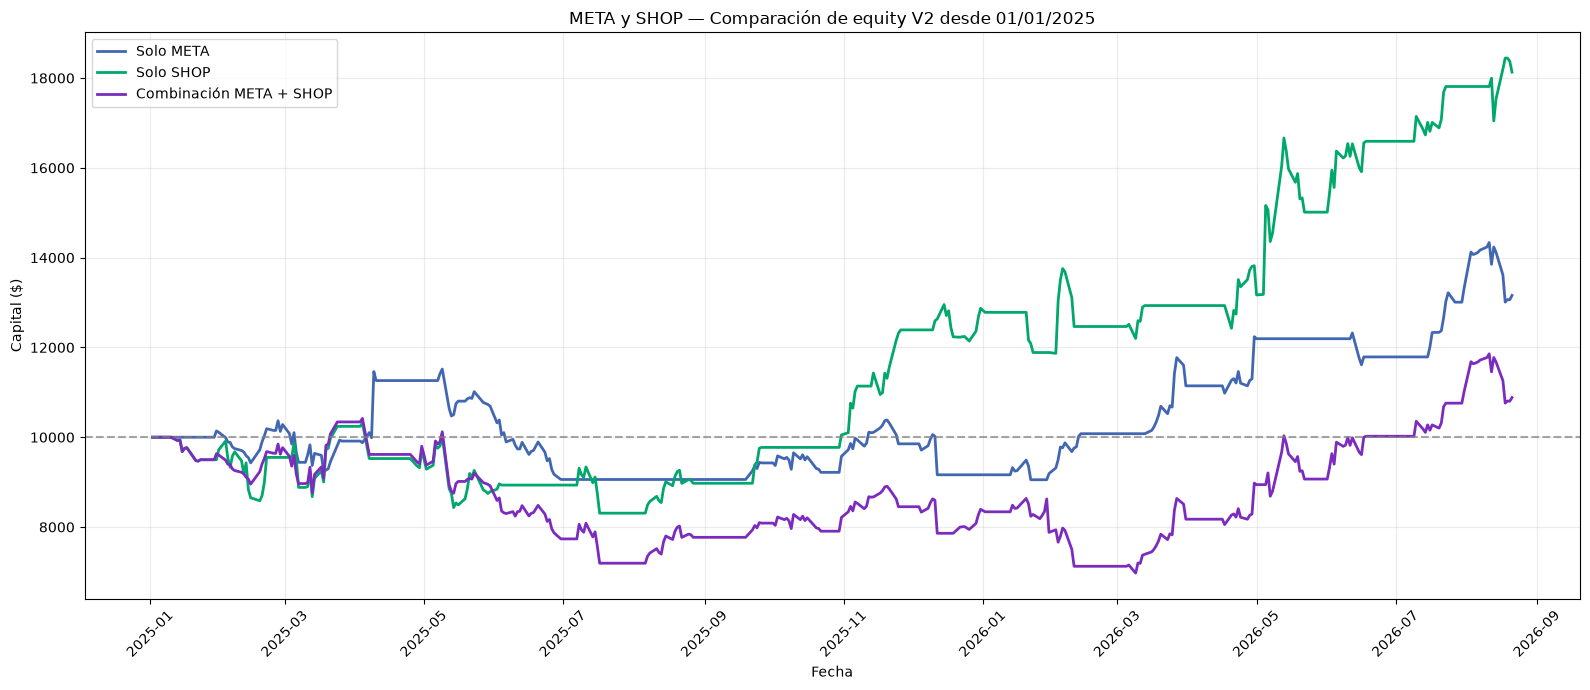

OPERACIONES DE LA COMBINACIÓN


,Ticker,Tipo,Sistema entrada,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %,Motivo
0,SHOP,SHORT,RUPTURA,2025-01-13 00:00:00,$101.00,2025-01-23 00:00:00,$106.06,-5.01%,DOS CIERRES SOBRE EMA10
1,META,SHORT,RSI > 70,2025-01-30 00:00:00,$696.82,2025-02-24 00:00:00,$686.28,+1.51%,SEÑAL SALIDA SHORT
2,META,LONG,RSI + BOLLINGER,2025-02-26 00:00:00,$659.65,2025-03-07 00:00:00,$613.47,-7.00%,STOP LOSS LONG
3,SHOP,LONG,RSI + BOLLINGER,2025-03-11 00:00:00,$92.75,2025-03-24 00:00:00,$106.95,+15.31%,SEÑAL SALIDA LONG
4,SHOP,SHORT,RUPTURA,2025-04-04 00:00:00,$77.48,2025-04-07 00:00:00,$82.90,-7.00%,STOP/TRAILING RUPTURA
5,SHOP,SHORT,RSI > 70,2025-04-28 00:00:00,$96.85,2025-05-12 00:00:00,$103.63,-7.00%,STOP LOSS SHORT
6,META,SHORT,RSI > 70,2025-05-13 00:00:00,$645.54,2025-06-05 00:00:00,$690.73,-7.00%,STOP LOSS SHORT
7,META,SHORT,RSI > 70,2025-06-06 00:00:00,$696.17,2025-06-30 00:00:00,$744.90,-7.00%,STOP LOSS SHORT
8,SHOP,SHORT,RSI > 70,2025-07-08 00:00:00,$117.41,2025-07-17 00:00:00,$125.63,-7.00%,STOP LOSS SHORT
9,SHOP,SHORT,RSI > 70,2025-08-07 00:00:00,$154.46,2025-08-27 00:00:00,$142.08,+8.02%,SEÑAL SALIDA SHORT


In [5]:
fig, ax = plt.subplots(figsize=(16, 7))
colores = {'Solo META': '#4267B2', 'Solo SHOP': '#00A86B',
           'Combinación META + SHOP': '#7B2CBF'}
for nombre, r in escenarios.items():
    ax.plot(r['Equity'].index, r['Equity']['Equity'], lw=2,
            label=nombre, color=colores[nombre])
ax.axhline(CAPITAL_INICIAL, color='gray', ls='--', alpha=.7)
ax.set_title('META y SHOP — Comparación de equity V2 desde 01/01/2025')
ax.set_xlabel('Fecha'); ax.set_ylabel('Capital ($)')
ax.grid(alpha=.25); ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
fig.savefig('META_SHOP_V2_Combi_equity.png', dpi=160, bbox_inches='tight')
display(fig); plt.close(fig)

print('OPERACIONES DE LA COMBINACIÓN')
ops_combi = pd.DataFrame(escenarios['Combinación META + SHOP']['Operaciones'])
display(ops_combi.style.format({
    'Precio entrada': '${:,.2f}', 'Precio salida': '${:,.2f}',
    'Rentabilidad %': '{:+.2f}%'
}))
